# A Flax Optimization Cookbook

This notebook goes through some common problems in nontrivial training loops for flax models. For clarity, all sections below will be training the following toy model. Both raw Jax and Flax code are shown for comparison.

In [1]:
import jax
from flax import nnx
jax.config.update('jax_num_cpu_devices', 8)
import jax.numpy as jnp
from jax import tree
import optax
import itertools as it
import functools as ft
from collections import namedtuple
import matplotlib.pyplot as plt

Here is the NNX version of the toy model we will be training. We allow extra keyword arguments so that the sharding and dtype can be determined on an instance by instance basis. 

In [2]:
param_init = jax.nn.initializers.lecun_normal()

nnx_keys = nnx.Rngs(0)

def nnx_model(rngs, **kwargs):
    return nnx.Sequential(
        nnx.Linear(2,8, rngs=rngs, kernel_init=ft.partial(param_init, **kwargs)),
        nnx.Linear(8,8, rngs=rngs, kernel_init=ft.partial(param_init, **kwargs)))

def nnx_loss_fn(model, x, y):
    return jnp.sum((model(x) - y) ** 2)

Here is the equivalent raw Jax representation. 

In [3]:
keys = map(ft.partial(jax.random.fold_in, jax.random.key(0)), it.count())

def make_linear(size, keys, **kwargs):
    return {
        'w': param_init(next(keys), size, **kwargs),
        'b': jnp.zeros(size[1])
    }
    
def jax_params(keys, **kwargs):
    return [make_linear((2, 8), keys), make_linear((8, 8), keys, **kwargs)]

def jax_model(params, x):
    for p in params:
        x = x @ p['w'] + p['b']
    return x

def jax_loss_fn(params, x, y):
    return jnp.sum((y - jax_model(params, x))**2)

We'll operate on the following fake data:

In [4]:
x = jax.random.normal(next(keys), (32, 2))
y = jax.random.normal(next(keys), (32, 8))

And we'll use ADAM to update.

In [5]:
optimizer = optax.adam(1e-3)

# Exponential Moving Average

Neural network see increased robustness when, rather than using only the weights available at the end of training, we use an exponential moving average of the weights produced throughout training. It is easy to modify the standard Jax training loop to accomodate calculating exponential moving averages. 

## EMA in Pure Jax

To start, we will see how to keep track of exponential moving averages in raw Jax. Although the raw Jax implementation is simple and easy to understand, it does not allow for mutable state. 

EMA LOSS  433.3479


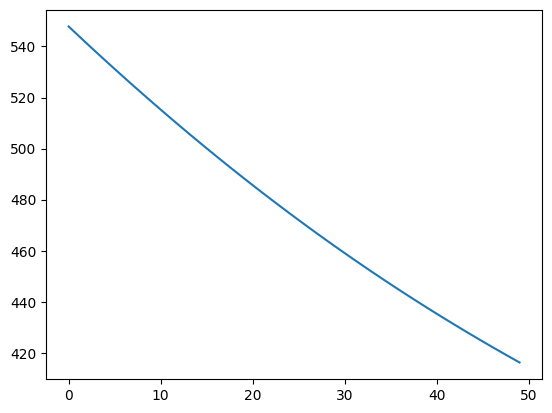

In [6]:
def ema_update(ema, new_val, decay=0.9):
    return decay * ema + (1 - decay) * new_val

@jax.jit
def train_step(opt_state, params, ema_params, x, y):
    loss, grads = jax.value_and_grad(jax_loss_fn)(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    ema_params = tree.map(ema_update, ema_params, params)
    return opt_state, params, ema_params, loss

params = jax_params(keys)
opt_state = optimizer.init(params)
ema_params = params

losses = []
for _ in range(50):
  opt_state, params, ema_params, loss = train_step(opt_state, params, ema_params, x, y)
  losses.append(loss)
plt.plot(losses)
print("EMA LOSS ", jax_loss_fn(ema_params, x, y))

## EMA in Flax

Now, we can see how to implement an exponential moving average in Flax. The code below is almost identical to the pure jax version above, but because NNX allows for mutable operations, we no longer need to explicitly return the state objects. 

EMA LOSS 316.71863


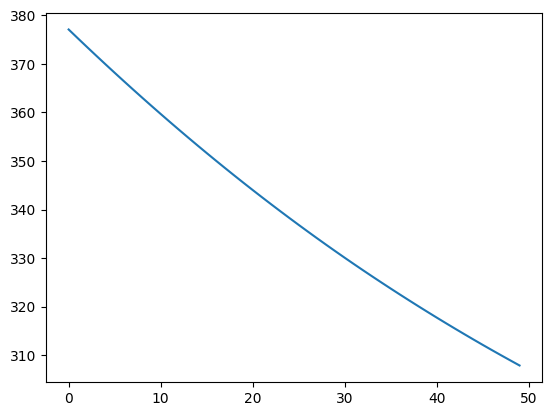

In [7]:
model = nnx_model(nnx_keys)

nnx_optimizer = nnx.Optimizer(
  model,
  tx=optimizer,
  wrt=nnx.Param,
)

class Ema(nnx.Module):
    def __init__(self, model):
        self.ema = nnx.merge(*nnx.split(model)) # Make a copy
    def update(self, model):
        self.ema = tree.map(ema_update, self.ema, model)

ema = Ema(model)

@nnx.jit
def train_step(model, nnx_optimizer, ema, x, y):
  loss, grads = nnx.value_and_grad(nnx_loss_fn)(model, x, y)
  nnx_optimizer.update(model, grads)
  ema.update(model)
  return loss

losses = []
for _ in range(50):
  loss = train_step(model, nnx_optimizer, ema, x, y)
  losses.append(loss)

plt.plot(losses)
print("EMA LOSS", nnx_loss_fn(ema.ema, x, y))

# Low Rank Adaptation

The pattern for adding low rank adaptation to an optimization loop is very similar to adding an exponential moving average. As before, we create a new pytree with the same structure as our model parameters, but here we store low rank additions to these parameters rather than weighted average values. 

## Lora in Jax

In [8]:
base_params = jax_params(keys)

def init_lora_param(a, k=2):
    if len(a.shape) == 2:
        return {'A': param_init(next(keys), (a.shape[0], k)), 'B': jnp.zeros((k, a.shape[1]))}
    else:
        return None

jax_lora_params = tree.map(init_lora_param, base_params)
opt_state = optimizer.init(jax_lora_params)

def apply_lora_param(base_params, lora_params):
    if lora_params is None:
        return base_params
    return base_params + (lora_params['A'] @ lora_params['B'])

def jax_lora_loss(lora_params, params, x, y):
    params = tree.map(apply_lora_param, params, lora_params)
    return jax_loss_fn(params, x, y)

@jax.jit
def train_step(params, lora_params, opt_state, x, y):
    loss, grads = jax.value_and_grad(jax_lora_loss)(lora_params, params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    lora_params = optax.apply_updates(lora_params, updates)
    return params, lora_params, opt_state, loss

losses = []
for _ in range(50):
  params, jax_lora_params, opt_state, loss = train_step(params, jax_lora_params, opt_state, x, y)
  losses.append(loss)

## LORA in Flax

If Flax, we just need to wrap the optax optimizer with `nnx.Optimizer` to provide a mutable interface. 

In [9]:
model = nnx_model(nnx_keys)
nnx_lora_params = tree.map(init_lora_param, model)

def nnx_lora_loss(lora_params, params, x, y):
    params = tree.map(apply_lora_param, params, lora_params)
    return nnx_loss_fn(params, x, y)

@nnx.jit
def nnx_lora_train_step(nnx_model, nnx_lora_params, nnx_optimizer, x, y):
  loss, grads = nnx.value_and_grad(nnx_lora_loss)(nnx_lora_params, nnx_model, x, y)
  nnx_optimizer.update(nnx_lora_params, grads)
  return loss

nnx_lora_optimizer = nnx.Optimizer(
  nnx_lora_params,
  tx=optimizer,
  wrt=nnx.Param,
)

losses = []
for _ in range(50):
  loss = nnx_lora_train_step(model, nnx_lora_params, nnx_lora_optimizer, x, y)
  losses.append(loss)

# LBFGS

So far, we've been using optax optimizers with the interface `optimizer.update(grads, opt_state)`. This works for simple optimization algorithms like ADAM, but for algorithms that use a line search like LBFGS, we need to pass more parameters. Below, we can see how the call to `optimizer.update` is given additional parameters when using LBFGS. 

## LBFGS in Jax

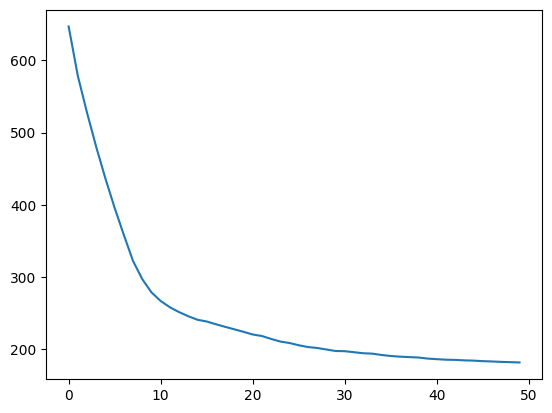

In [10]:
@jax.jit
def train_step(x, y, params, opt_state):
    local_loss = lambda p: jax_loss_fn(p, x, y)
    value_and_grad_fn = optax.value_and_grad_from_state(local_loss)
    loss, grad = value_and_grad_fn(params, state=opt_state)
    updates, opt_state = lbfgs.update(grad, opt_state, params,
                                      value=loss, grad=grad, value_fn=local_loss)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

params = jax_params(keys)
opt_state = lbfgs.init(params)

losses = []
for _ in range(50):
  params, opt_state, loss = train_step(x, y, params, opt_state)
  losses.append(loss)
plt.plot(losses);

## LBFGS in Flax

Flax's Optimizers aren't currently capable of handling the extra parameters used by the line search in LBFGS. But fortunately, you don't need to use Flax's Optimizer class. Standard Optax optimizers work just fine as long as you're willing to adopt a functional programming style.

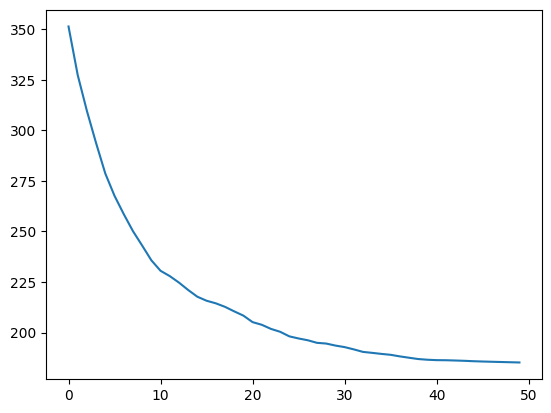

In [11]:
@jax.jit
def train_step(x, y, params, opt_state):
    local_loss = lambda p: nnx_loss_fn(p, x, y)
    value_and_grad_fn = optax.value_and_grad_from_state(local_loss)
    loss, grad = value_and_grad_fn(params, state=opt_state)
    updates, opt_state = lbfgs.update(grad, opt_state, params,
                                      value=loss, grad=grad, value_fn=local_loss)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

model = nnx_model(nnx_keys)
opt_state = lbfgs.init(model)

losses = []
for _ in range(50):
  model, opt_state, loss = train_step(x, y, model, opt_state)
  losses.append(loss)
plt.plot(losses);

# Per-Parameter Learning Rates

In some training regimes, you will want to optimize different parameters with different learning rates. 

## In Jax

First, we map from each leaf to the type of parameter it is (weight or bias).

In [12]:
params = jax_params(keys)
param_tys = jax.tree.map_with_path(lambda p, _: p[-1].key, params)

Next, we create a dictionary giving the learning rates to use for each parameter type.

In [13]:
rates = {'w': optax.adam(1e-3), 'b': optax.adam(1e-2)}

Finally, we can make a compound optimizers that uses each rate appropriately. 

In [14]:
joint_optimizer = optax.partition(rates, param_tys)
opt_state = joint_optimizer.init(params)

The rest of the training loop proceeds as usual.

In [15]:
@jax.jit
def train_step(opt_state, params, x, y):
    loss, grads = jax.value_and_grad(jax_loss_fn)(params, x, y)
    updates, opt_state = joint_optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return opt_state, params, loss

losses = []
for _ in range(50):
  opt_state, params, loss = train_step(opt_state, params, x, y)
  losses.append(loss)

## In Flax

In Flax, we will also initialize a partitioned optax optimizer. But unlike the Jax case where we use model as the PyTree, we'll need to use the model's *state* PyTree here instead. These state PyTrees aren't compatible with ordinary jax tree mapping; instead of `jax.tree.map_with_path`, we'll need to use the NNX version, which is called `nnx.map_state`. 

In [16]:
model = nnx_model(nnx_keys)
state = nnx.state(model, nnx.Param)
rates = {'kernel': optax.adam(1e-3), 'bias': optax.adam(1e-2)}
param_tys = nnx.map_state(lambda p, v: list(p)[-1], state)
joint_optimizer = optax.partition(rates, param_tys)
nnx_optimizer = nnx.Optimizer(model, tx=joint_optimizer, wrt=nnx.Param)

@nnx.jit
def nnx_train_step(model, nnx_optimizer, x, y):
  loss, grads = nnx.value_and_grad(nnx_loss_fn)(model, x, y)
  nnx_optimizer.update(model, grads)
  return loss

losses = []
for _ in range(50):
  loss = nnx_train_step(model, nnx_optimizer, x, y)
  losses.append(loss)

# Gradient Accumulation

## In Jax

Gradient accumulation in raw Jax is easy: just wrap your optimizer in `optax.MultiSteps`.

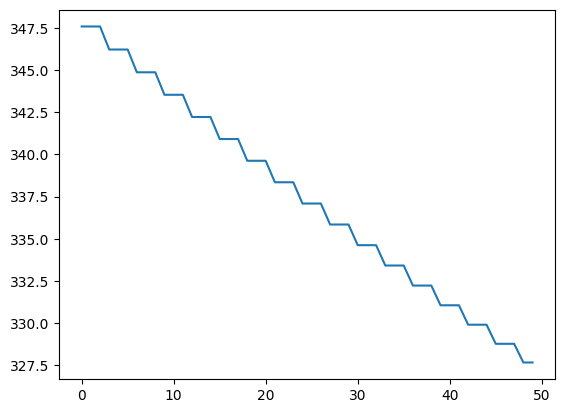

In [17]:
params = jax_params(keys)
mult_opt = optax.MultiSteps(optimizer, every_k_schedule=3)
opt_state = mult_opt.init(params)

@jax.jit
def train_step(opt_state, params, x, y):
    loss, grads = jax.value_and_grad(jax_loss_fn)(params, x, y)
    updates, opt_state = mult_opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return opt_state, params, loss

losses = []
for _ in range(50):
  opt_state, params, loss = train_step(opt_state, params, x, y)
  losses.append(loss)
plt.plot(losses);

## In Flax

In Flax, we can just wrap wrap the `MultiSteps` optimizer with the `nnx.Optimizer` class to get the same result. 

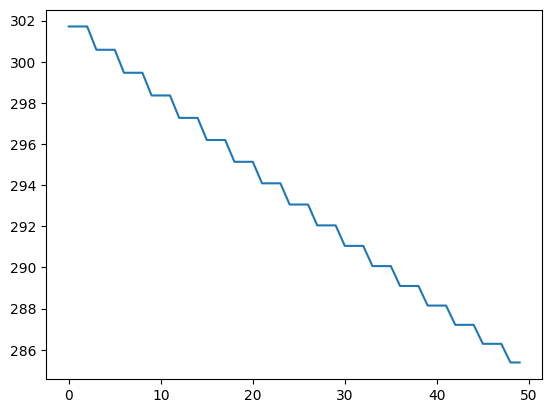

In [18]:
model = nnx_model(nnx_keys)
nnx_optimizer = nnx.Optimizer(model, tx=mult_opt, wrt=nnx.Param)

@nnx.jit
def nnx_train_step(model, nnx_optimizer, x, y):
  loss, grads = nnx.value_and_grad(nnx_loss_fn)(model, x, y)
  nnx_optimizer.update(model, grads)
  return loss

losses = []
for _ in range(50):
  loss = nnx_train_step(model, nnx_optimizer, x, y)
  losses.append(loss)
plt.plot(losses);

# Sharding Optimization State Differently from Parameters

## Jax Version

Say we're doing data parallelism. We want to replicate our parameters across all GPUs so we can do the forward and backward passes without communication latency. 

But we don't need to replicate the optimizer state, as it's not invovled in SPMD computations. One copy is enough, and we can shard this copy across our mesh to reduce memory usage. This means that we need the optimier state to be sharded differently from the parameters themselves.

To do this, we can pass the params initializer given the the optimizer a `sharding` argument. This will shard the optimization state the same way. But when we initialize the model parameters themselves, we won't provide a sharding, allowing for data parallelism. 

In [19]:
from jax.sharding import PartitionSpec as P, AxisType, get_abstract_mesh, reshard

mesh = jax.make_mesh((2, 4), ("x", "y"),
                     axis_types=(AxisType.Explicit, AxisType.Explicit))
jax.set_mesh(mesh)

opt_state = optimizer.init(jax.eval_shape(lambda: jax_params(keys, out_sharding=P('x', 'y'))))
params = jax_params(keys)

@jax.jit
def train_step(opt_state, params, x, y):
    loss, grads = jax.value_and_grad(jax_loss_fn)(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return opt_state, params, loss

losses = []
for _ in range(50):
  opt_state, params, loss = train_step(opt_state, params, x, y)
  losses.append(loss)

## Flax Version

The pattern above applies equally well to Flax models:

In [22]:
ghost_model = jax.eval_shape(lambda: nnx_model(nnx.Rngs(0), out_sharding=P('x', 'y')))
nnx_optimizer = nnx.Optimizer(ghost_model, optax.adam(1e-3), wrt=nnx.Param)
model = nnx_model(nnx.Rngs(0))

@nnx.jit
def nnx_train_step(model, nnx_optimizer, x, y):
  loss, grads = nnx.value_and_grad(nnx_loss_fn)(model, x, y)
  nnx_optimizer.update(model, grads)
  return loss

losses = []
for _ in range(50):
  loss = nnx_train_step(model, nnx_optimizer, x, y)
  losses.append(loss)

In [ ]:
jax.typeof(nnx_optimizer.opt_state[0].mu['kernel'][...])